# Random forest climatology: Global air temperature observations

In this notebook, we model temperature over the global region using a random forest model.
We load observations data with additional predictors (roughness, land fraction), apply suitable transformations.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

Model and libraries:
We use scikit-learn to build random forest based climatology models and evaluate them with MAE metric.
Furthermore, we create various visual plots to analyse the results.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
import matplotlib.patheffects as pe

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

#Random Forest Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

2.19.0


## Loading Observations

In [3]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

(9232630, 9)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness'],
      dtype='object')
-79.64999999999998
58.25


In [4]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615


## Data Transformations

In [6]:
# Transforming date to a cyclic pattern in a 365 day cycle (obs -> observations)
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour
obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)
# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)

# Transforming latitude, longitude
obs['sin_lat'] = np.sin(np.radians(obs['latitude'])).round(5)
obs['cos_lat'] = np.cos(np.radians(obs['latitude'])).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)
# Converting temperature from Kelvin to Celsius 
obs['temp_celcius'] = obs['ob_value'] - 273.15

In [7]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.99452,0.10453,-0.98324,0.18234,-18.15
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,4,0.52342,0.85208,-0.33371,0.94268,-0.99452,0.10453,-0.98324,0.18234,-18.35
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,6,0.52342,0.85208,0.18234,0.98324,-0.99452,0.10453,-0.98324,0.18234,-17.85
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,7,0.52342,0.85208,0.43061,0.90254,-0.99452,0.10453,-0.98324,0.18234,-17.65
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,8,0.52342,0.85208,0.64953,0.76034,-0.99452,0.10453,-0.98324,0.18234,-17.85
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,9,0.52342,0.85208,0.82419,0.56632,-0.99452,0.10453,-0.98324,0.18234,-18.65
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,10,0.52342,0.85208,0.94268,0.33371,-0.99452,0.10453,-0.98324,0.18234,-18.65
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,12,0.52342,0.85208,0.98324,-0.18234,-0.99452,0.10453,-0.98324,0.18234,-19.05
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,13,0.52342,0.85208,0.90254,-0.43061,-0.99452,0.10453,-0.98324,0.18234,-19.55
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,19,0.52342,0.85208,-0.43061,-0.90254,-0.99452,0.10453,-0.98324,0.18234,-17.75


## Random Forest Regressor using Scikit-Learn 

### Data Preparation

In [11]:
df = obs.copy()
df.columns

Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness', 'day_of_year', 'hour',
       'sin_day', 'cos_day', 'sin_hour', 'cos_hour', 'sin_lat', 'cos_lat',
       'sin_long', 'cos_long', 'temp_celcius'],
      dtype='object')

In [12]:
#Splitting dataset into train, test and validation set with a ratio of 70:15:15.
unique_wmo_ids = df['wmo_id'].unique()
unique_wmo_ids.shape
np.random.seed(0)
np.random.shuffle(unique_wmo_ids)

#Splitting data by 70-30 ratio
split_index = int(0.7 * len(unique_wmo_ids))
train_ids = unique_wmo_ids[:split_index]

split_index_1 = int(0.5 * (len(unique_wmo_ids) - len(train_ids)))
val_ids = unique_wmo_ids[split_index : (split_index + split_index_1)]
test_ids = unique_wmo_ids[(split_index + split_index_1):]

df_train = df[df['wmo_id'].isin(train_ids)]
df_val = df[df['wmo_id'].isin(val_ids)]
df_test = df[df['wmo_id'].isin(test_ids)]

print(train_ids.shape)
print(val_ids.shape)
print(test_ids.shape)
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)


(5499,)
(1178,)
(1179,)
(6432675, 20)
(1397845, 20)
(1402110, 20)


### Visualising train, test sites and storing data for visualisations

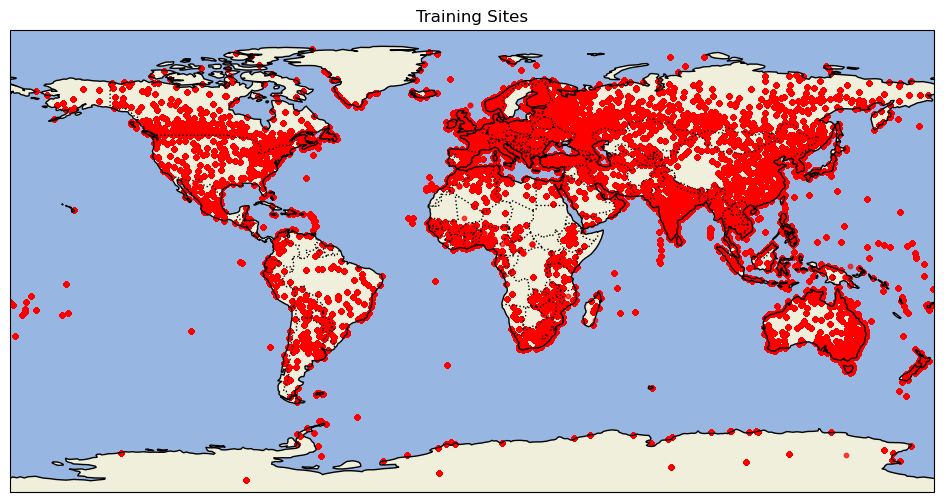

In [14]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_train['longitude'], df_train['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Training Sites")
plt.show()

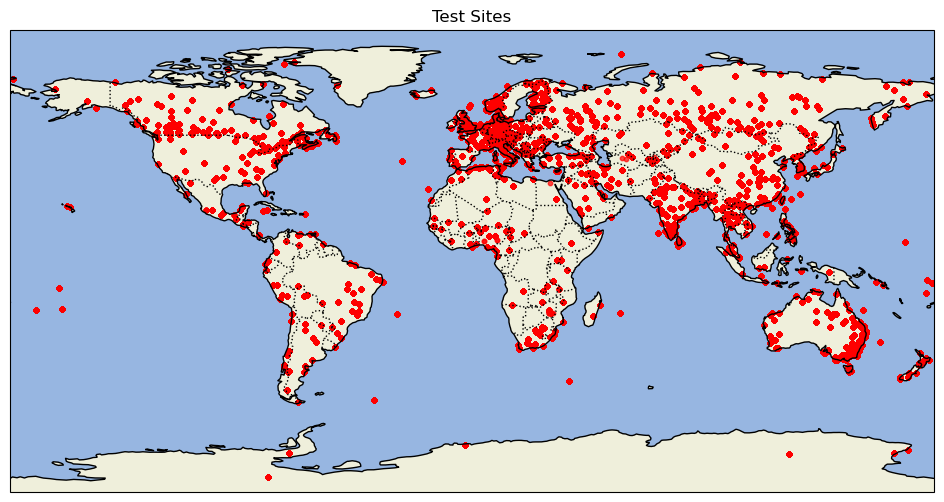

In [15]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_test['longitude'], df_test['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Test Sites")
plt.show()

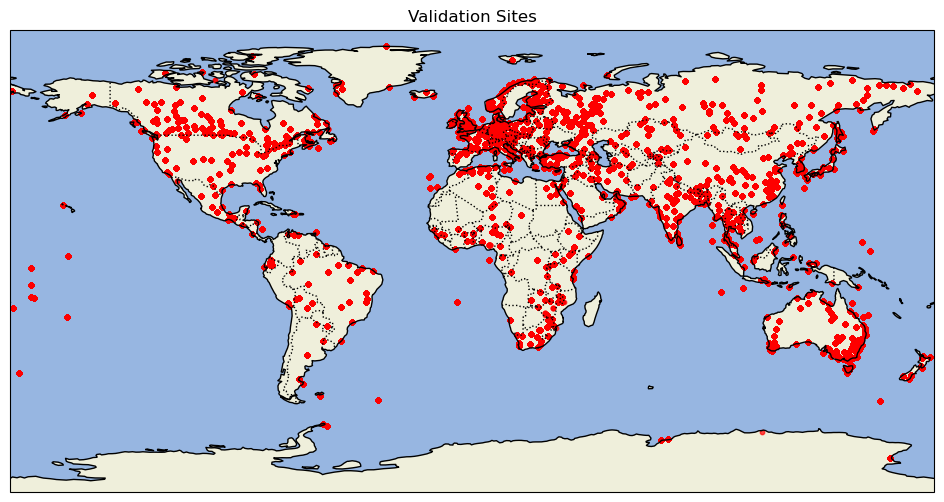

In [16]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(df_val['longitude'], df_val['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Validation Sites")
plt.show()

In [17]:
map_values = df_test[['latitude', 'longitude','altitude', 'temp_celcius', 'day_of_year', 'hour']]
map_values

,latitude,longitude,altitude,temp_celcius,day_of_year,hour
0,-84.000,-79.494,1285.0,-18.15,32,2
1,-84.000,-79.494,1285.0,-18.35,32,4
2,-84.000,-79.494,1285.0,-17.85,32,6
3,-84.000,-79.494,1285.0,-17.65,32,7
4,-84.000,-79.494,1285.0,-17.85,32,8
...,...,...,...,...,...,...
9232600,80.626,58.059,21.0,-6.35,139,21
9232613,80.626,58.059,21.0,-6.75,140,0
9232614,80.626,58.059,21.0,-6.85,140,3
9232626,80.626,58.059,21.0,-6.05,140,6


### Training Data

In [19]:
df_train = df_train.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_val = df_val.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_test = df_test.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])

df_test

,altitude,land_fraction,roughness,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
0,1285.0,1.000000,0.000615,0.52342,0.85208,-0.76034,0.64953,-0.99452,0.10453,-0.98324,0.18234,-18.15
1,1285.0,1.000000,0.000615,0.52342,0.85208,-0.33371,0.94268,-0.99452,0.10453,-0.98324,0.18234,-18.35
2,1285.0,1.000000,0.000615,0.52342,0.85208,0.18234,0.98324,-0.99452,0.10453,-0.98324,0.18234,-17.85
3,1285.0,1.000000,0.000615,0.52342,0.85208,0.43061,0.90254,-0.99452,0.10453,-0.98324,0.18234,-17.65
4,1285.0,1.000000,0.000615,0.52342,0.85208,0.64953,0.76034,-0.99452,0.10453,-0.98324,0.18234,-17.85
...,...,...,...,...,...,...,...,...,...,...,...,...
9232600,21.0,0.033826,0.030000,0.68077,-0.73249,0.22595,0.97414,0.98665,0.16288,0.84859,0.52905,-6.35
9232613,21.0,0.033826,0.030000,0.66806,-0.74410,0.84859,0.52905,0.98665,0.16288,0.84859,0.52905,-6.75
9232614,21.0,0.033826,0.030000,0.66806,-0.74410,0.97414,-0.22595,0.98665,0.16288,0.84859,0.52905,-6.85
9232626,21.0,0.033826,0.030000,0.66806,-0.74410,0.52905,-0.84859,0.98665,0.16288,0.84859,0.52905,-6.05


In [20]:
X_train = df_train.iloc[:, :11].values
y_train = df_train.iloc[:, 11].values
X_val = df_val.iloc[:, :11].values
y_val = df_val.iloc[:, 11].values
X_test = df_test.iloc[:, :11].values
y_test = df_test.iloc[:, 11].values

y_test.max()

47.35000000000002

In [21]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape

(6432675, 11)

### Fitting a Random Forest

In [27]:
# Create and train a Random Forest Regression model
model = RandomForestRegressor(n_estimators=100, random_state=42, 
                                     criterion='squared_error', max_depth=50, 
                                     min_samples_split=2, min_samples_leaf=1, bootstrap=True, warm_start=True, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Save model

In [60]:
##save
#joblib.dump(model, "./saved_models/RF_model_v1.joblib")

['./saved_models/RF_model_v1.joblib']

### Evaluate 

In [48]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 1.666697652896082


In [62]:
# Average depth of each tree
depths = [estimator.tree_.max_depth for estimator in model.estimators_]
print("Average depth:", np.mean(depths))


Average depth: 52.58


### Visualisation of results

In [50]:
## creating a dataframe to store visualise outputs and plot against predictors

tempdf = pd.DataFrame({
    'latitude' : map_values['latitude'],
    'longitude' : map_values['longitude'],
    'altitude' : map_values['altitude'],
    'day_of_year' : map_values['day_of_year'],
    'y_test' : y_test,
    'predicted' : preds.reshape(-1),
    'error' : y_test-preds.reshape(-1)
})

tempdf_grouped = tempdf.groupby(['y_test'], as_index = False).agg({
    'predicted' : ['mean', 'std']
})

tempdf

,latitude,longitude,altitude,day_of_year,y_test,predicted,error
0,-84.000,-79.494,1285.0,32,-18.0,-29.321,11.321
1,-84.000,-79.494,1285.0,32,-18.2,-30.060,11.860
2,-84.000,-79.494,1285.0,32,-17.7,-31.141,13.441
3,-84.000,-79.494,1285.0,32,-17.5,-31.103,13.603
4,-84.000,-79.494,1285.0,32,-17.7,-30.994,13.294
...,...,...,...,...,...,...,...
9232600,80.626,58.059,21.0,139,-6.2,-3.591,-2.609
9232613,80.626,58.059,21.0,140,-6.6,-3.719,-2.881
9232614,80.626,58.059,21.0,140,-6.7,-3.900,-2.800
9232626,80.626,58.059,21.0,140,-5.9,-3.233,-2.667


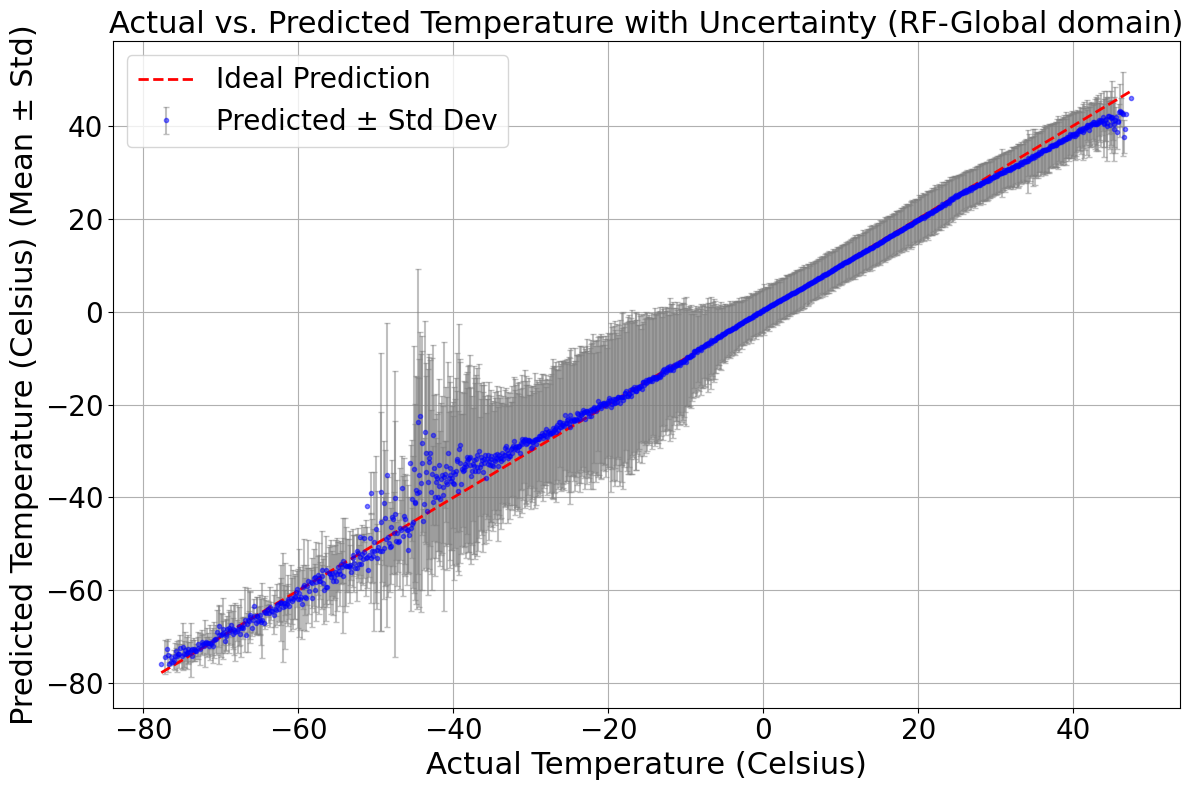

In [58]:
# Actual vs. Predicted Temperature with Uncertainty (RF-Global domain)

#errors = tempdf_grouped['predicted']['mean'] - tempdf_grouped['y_test'])
#errors = errors.astype(int)
plt.figure(figsize=(12, 8))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=2*tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=3,
             ecolor='gray', capsize=2, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Ideal Prediction', linewidth=2)

plt.xlabel('Actual Temperature (Celsius)', fontsize=22)
plt.ylabel('Predicted Temperature (Celsius) (Mean ± Std)', fontsize=22)
plt.title('Actual vs. Predicted Temperature with Uncertainty (RF-Global domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_1252/1549117496.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


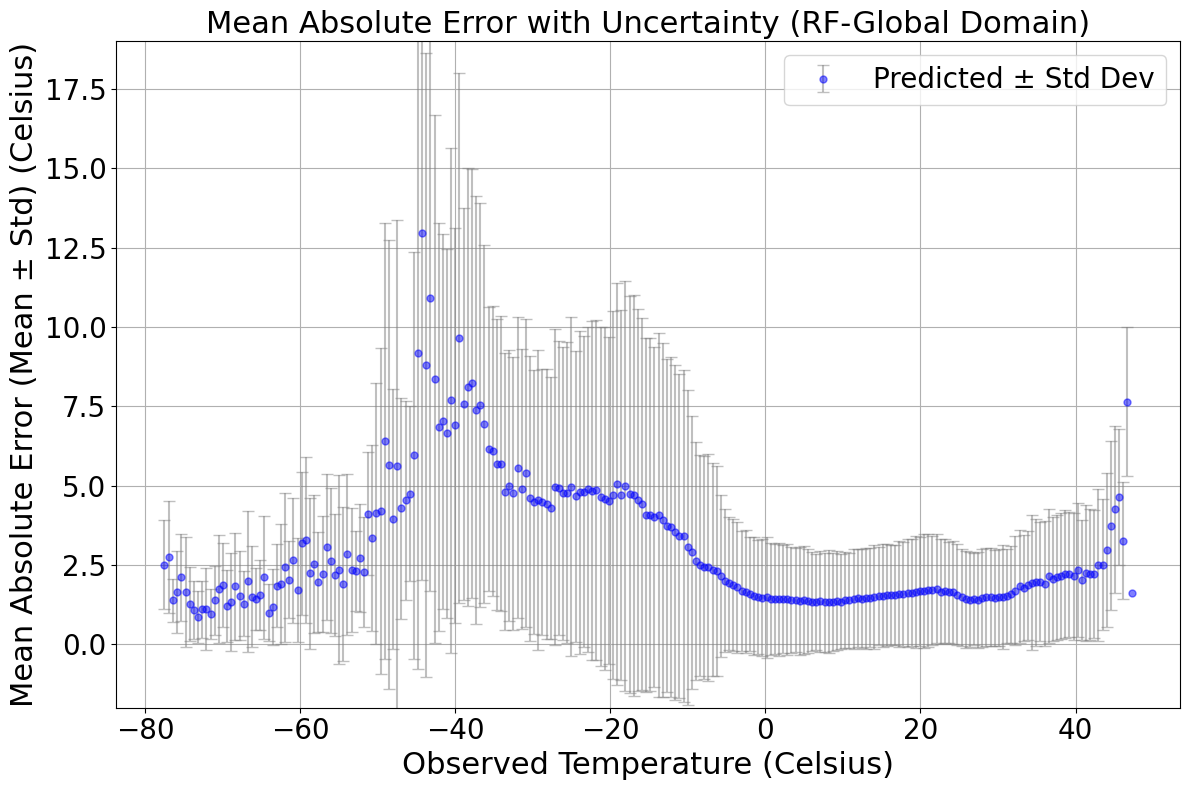

In [66]:
## Mean of MAE within temperature bins. the temperature range has been divided into 234 bins.

temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = np.abs(tempdf1['error'])
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

plt.ylim(-2,19)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Mean Absolute Error (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Mean Absolute Error with Uncertainty (RF-Global Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


In [84]:
temp_bins = pd.cut(tempdf['y_test'], bins=234)
temp_bins

0          (-18.31, -17.775]
1          (-18.31, -17.775]
2          (-17.775, -17.24]
3          (-17.775, -17.24]
4          (-17.775, -17.24]
                 ...        
9232600     (-6.539, -6.004]
9232613     (-7.074, -6.539]
9232614     (-7.074, -6.539]
9232626     (-6.004, -5.469]
9232627     (-6.004, -5.469]
Name: y_test, Length: 1402110, dtype: category
Categories (234, interval[float64, right]): [(-77.825, -77.165] < (-77.165, -76.63] < (-76.63, -76.095] < (-76.095, -75.56] ... (45.36, 45.895] < (45.895, 46.43] < (46.43, 46.965] < (46.965, 47.5]]

/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_1252/3847502595.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


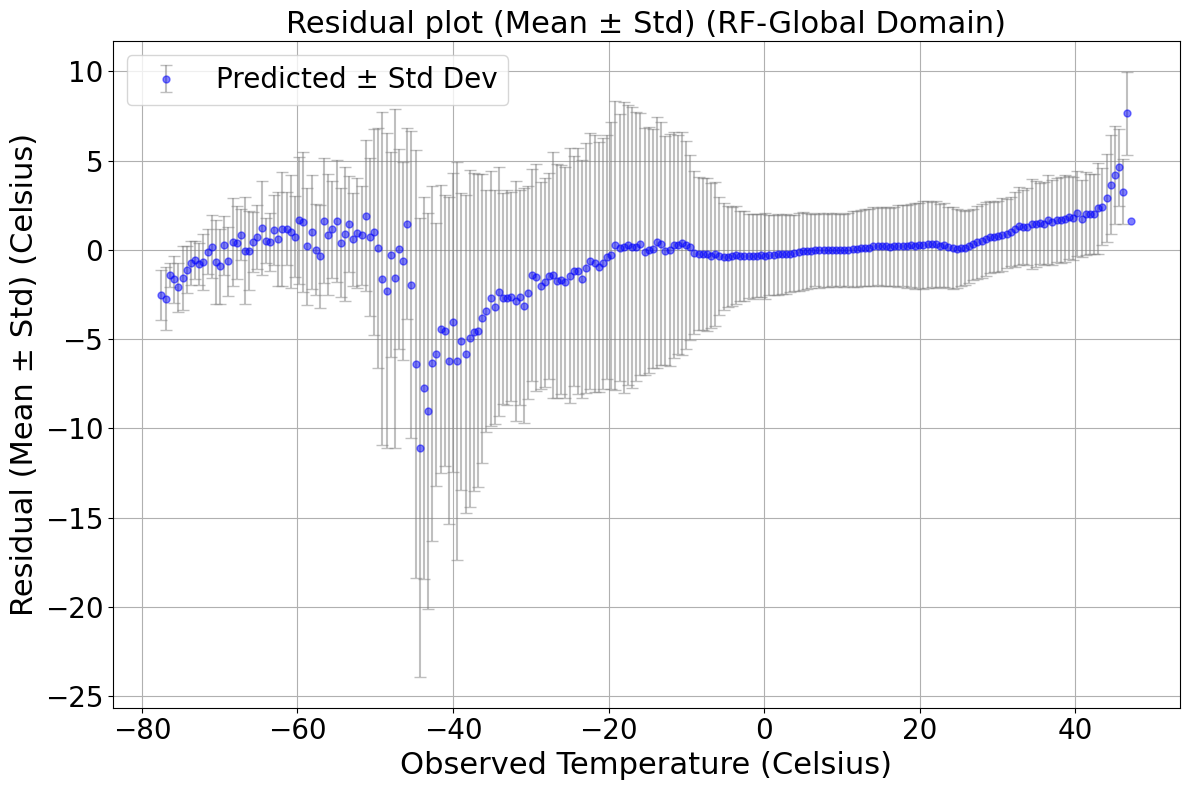

In [68]:
## Mean of residuals within temperature bins. the temperature range has been divided into 234 bins.

temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = tempdf1['error']
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.ylim(-2,19)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Residual (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Residual plot (Mean ± Std) (RF-Global Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


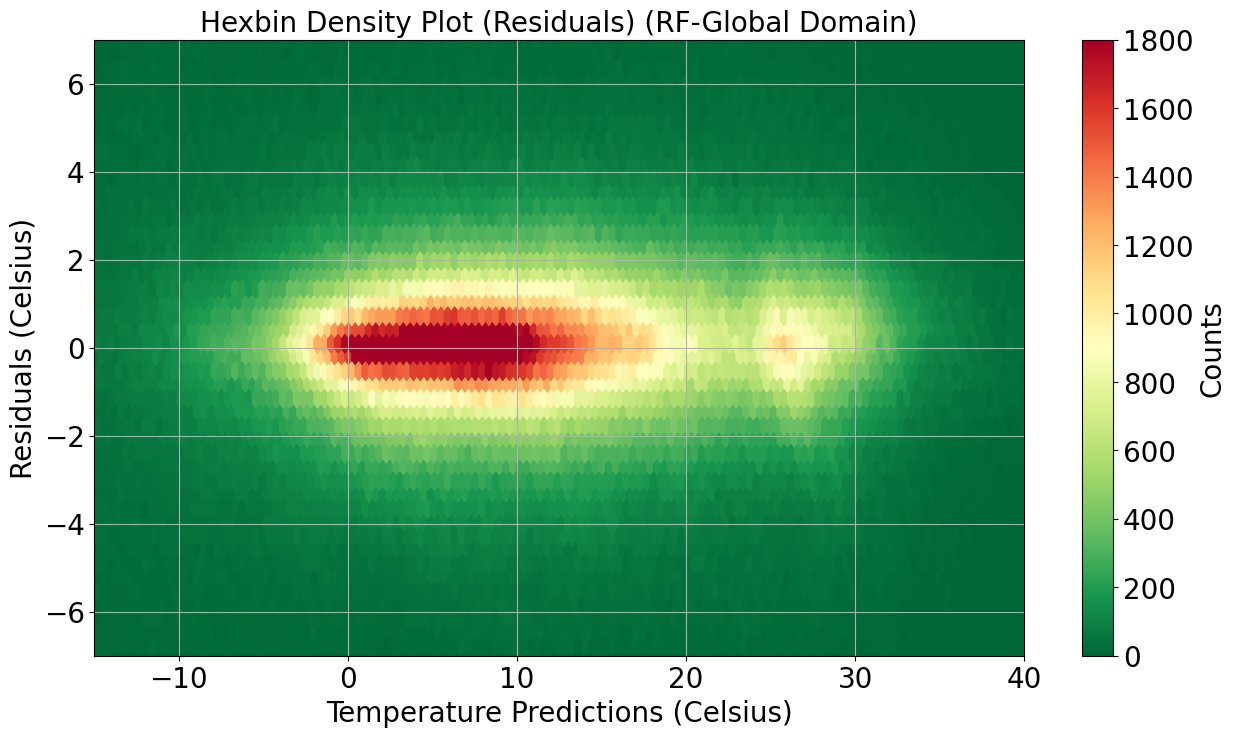

In [80]:
# Residual density plot

plt.figure(figsize=(15,8))
hb = plt.hexbin(
    tempdf['predicted'],
    tempdf['y_test'] - tempdf['predicted'],
    gridsize=300,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=1800
)

cbar = plt.colorbar(hb)                 # get the colorbar for the hexbin
cbar.set_label('Counts', fontsize=20)   # label size
cbar.ax.tick_params(labelsize=20)       # TICK label size

plt.xlabel('Temperature Predictions (Celsius)', fontsize=20)
plt.ylabel('Residuals (Celsius)', fontsize=20)
plt.title('Hexbin Density Plot (Residuals) (RF-Global Domain)', fontsize=20)
plt.ylim(-7, 7)
plt.xlim(-15, 40)
plt.grid(True); plt.xticks(fontsize=20); plt.yticks(fontsize=20)
plt.show()


Text(0.5, 1.0, 'Actual vs Predicted Temperature (Test Set)')

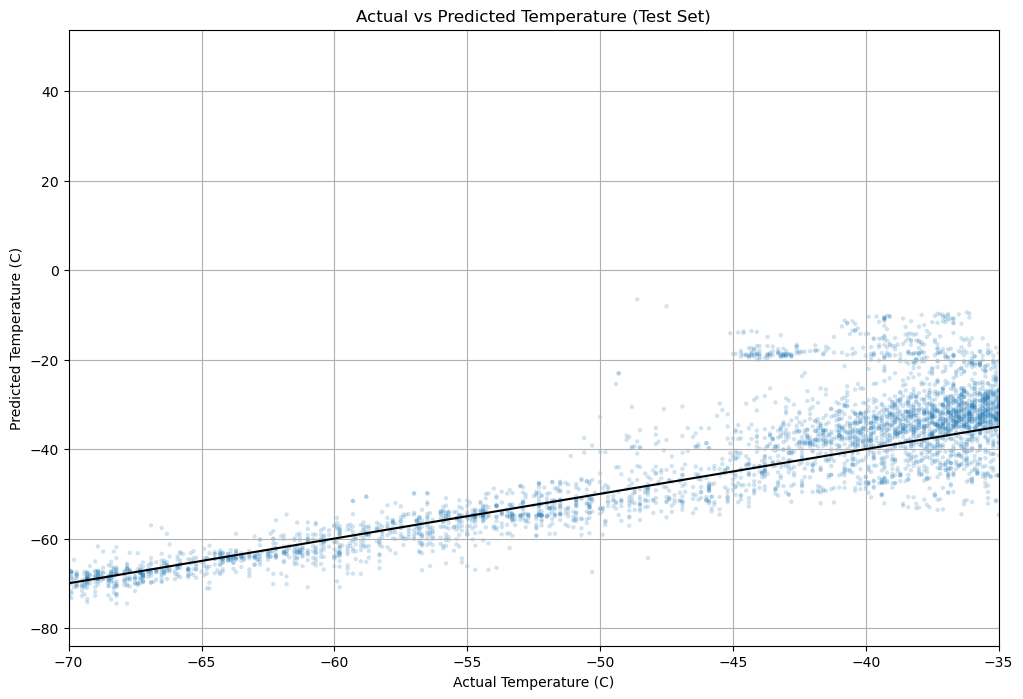

In [74]:
#Temp -70 to -35 celsius: actual vs predictted temperature

plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, s=10, alpha=0.2, edgecolors='none')
x_ = np.linspace(y_test.min(), y_test.max(), 100)
y_ = x_
plt.plot(x_, y_, color = 'black')
plt.grid(True)
plt.xlim(-70,-35)
#plt.ylim(-80,-5)
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title('Actual vs Predicted Temperature (Test Set)')

1402110


Text(0.5, 1.0, 'Residual Plot (-70 to -35 C Test values)')

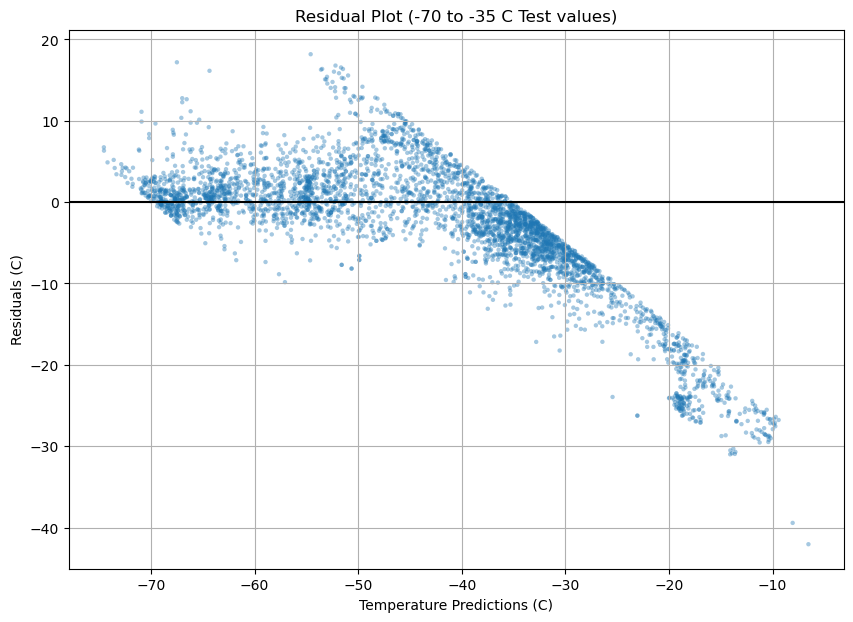

In [90]:
#Residual plot: -70 to -35 celsius. 
#A strange pattern is observed in this range.

low_temp_test_data = tempdf[(tempdf['y_test'] > -70) & (tempdf['y_test'] < -35)]
print(map_values.shape[0])
resids = low_temp_test_data['y_test'] - low_temp_test_data['predicted'] 

plt.figure(figsize=(10,7))
plt.scatter(low_temp_test_data['predicted'], resids, s=10, alpha=0.4, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim((-20,40))
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot (-70 to -35 C Test values)')

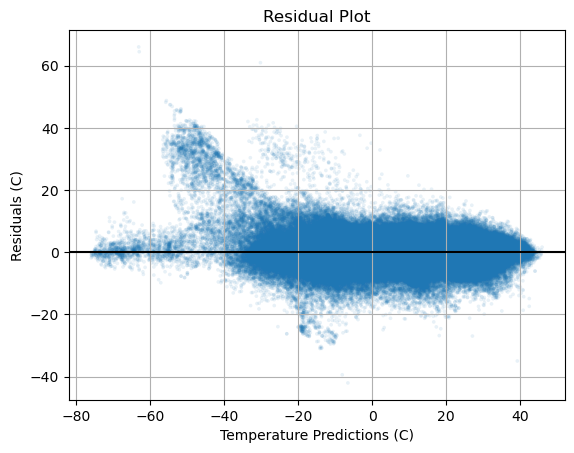

In [90]:
#Basic residual plot

resids = tempdf['y_test'] - tempdf['predicted'] 
plt.scatter(tempdf['predicted'], resids, s=7, alpha=0.1, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim(-7.5,10)
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot')
plt.show()

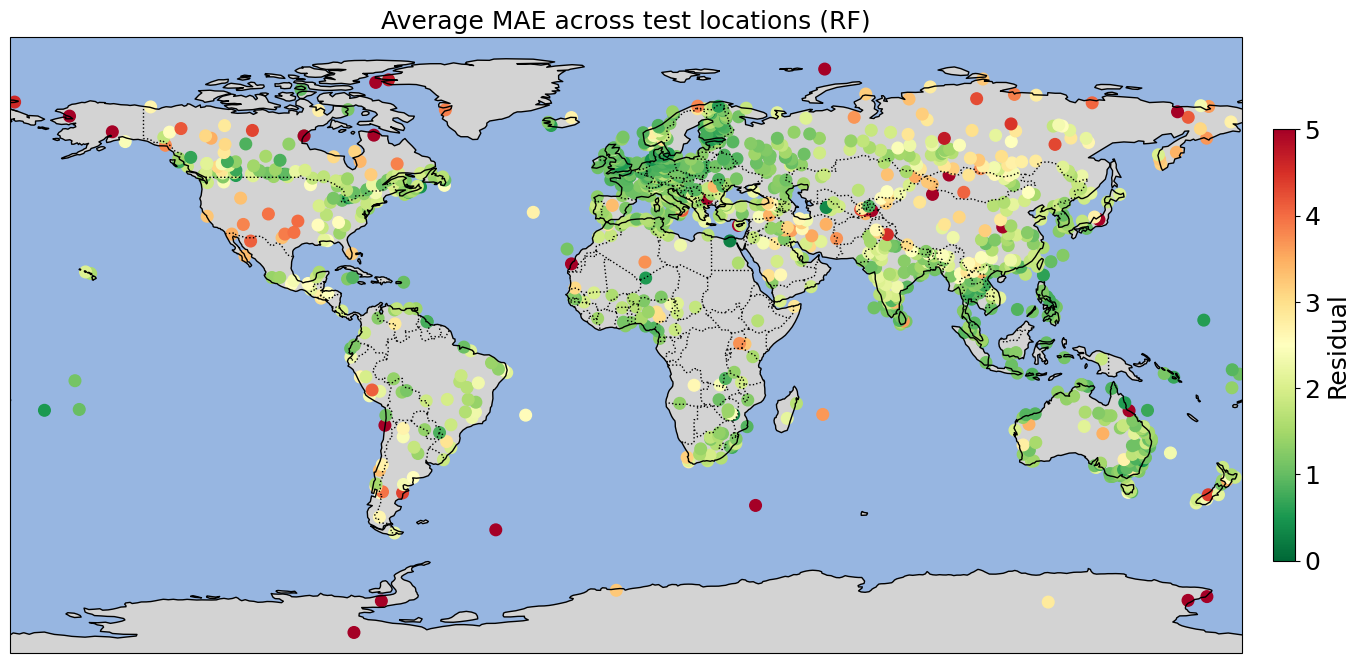

In [78]:
# MAE spatial distribution map

unique_test_locs = tempdf.copy()
unique_test_locs['error'] = np.abs(unique_test_locs['error'])
unique_test_locs = unique_test_locs.groupby(['latitude', 'longitude'])['error'].mean().reset_index()

# Create a map
plt.figure(figsize=(20, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()
z = np.abs(unique_test_locs['error'])
# Plot points
sc = ax.scatter(unique_test_locs['longitude'], unique_test_locs['latitude'], s=70, c=z, alpha=1, transform=ccrs.PlateCarree(), cmap='RdYlGn_r', vmin=0, vmax=5)

# Colorbar for residual intensity
#plt.colorbar(sc, ax=ax, orientation='vertical', label='Residual')
plt.title("Average MAE across test locations (RF)", fontsize=18)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Residual', fontsize=18)   # colorbar title size
cbar.ax.tick_params(labelsize=18) 
plt.show()